In [7]:
import os

print(os.getcwd())
print(os.listdir())

/drive/notebooks
['Intro.ipynb', 'Netflix_Business_Insights_Report.ipynb', 'Untitled1.ipynb', 'Untitled3.ipynb', 'ecommerce_customer_churn_dataset.csv', 'netflix_cleaned.csv', 'netflix_titles.csv', 'netflix_titles.csv.zip', 'r.ipynb', 'Lorenz.ipynb', 'Mandelbrot.ipynb', 'sqlite.ipynb', 'cpp.ipynb', 'cpp-third-party-libs.ipynb', 'cpp-tiny-ray-tracer.ipynb']


In [ ]:
step 1 - Data Collection

In [ ]:
Step 2 – Data Loading and Initial Data Inspection

In [8]:
import pandas as pd

df = pd.read_csv("ecommerce_customer_churn_dataset.csv")

print(df.head())

    Age  Gender Country        City  Membership_Years  Login_Frequency  \
0  43.0    Male  France   Marseille               2.9             14.0   
1  36.0    Male      UK  Manchester               1.6             15.0   
2  45.0  Female  Canada   Vancouver               2.9             10.0   
3  56.0  Female     USA    New York               2.6             10.0   
4  35.0    Male   India       Delhi               3.1             29.0   

   Session_Duration_Avg  Pages_Per_Session  Cart_Abandonment_Rate  \
0                  27.4                6.0                   50.6   
1                  42.7               10.3                   37.7   
2                  24.8                1.6                   70.9   
3                  38.4               14.8                   41.7   
4                  51.4                NaN                   19.1   

   Wishlist_Items  ...  Email_Open_Rate  Customer_Service_Calls  \
0             3.0  ...             17.9                     9.0   
1     

In [ ]:
Step 3 – Data Cleaning

In [9]:
print(df.isnull().sum())

Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64


In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
print("Rows and Columns:", df.shape)

Rows and Columns: (50000, 25)


In [13]:
df = df.fillna(df.median(numeric_only=True))

In [14]:
print(df.isnull().sum())

Age                              0
Gender                           0
Country                          0
City                             0
Membership_Years                 0
Login_Frequency                  0
Session_Duration_Avg             0
Pages_Per_Session                0
Cart_Abandonment_Rate            0
Wishlist_Items                   0
Total_Purchases                  0
Average_Order_Value              0
Days_Since_Last_Purchase         0
Discount_Usage_Rate              0
Returns_Rate                     0
Email_Open_Rate                  0
Customer_Service_Calls           0
Product_Reviews_Written          0
Social_Media_Engagement_Score    0
Mobile_App_Usage                 0
Payment_Method_Diversity         0
Lifetime_Value                   0
Credit_Balance                   0
Churned                          0
Signup_Quarter                   0
dtype: int64


In [15]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
Step 4 – Exploratory Data Analysis (EDA)

In [16]:
print(df["Churned"].value_counts())

Churned
0    35550
1    14450
Name: count, dtype: int64


In [17]:
print(df["Churned"].value_counts(normalize=True) * 100)

Churned
0    71.1
1    28.9
Name: proportion, dtype: float64


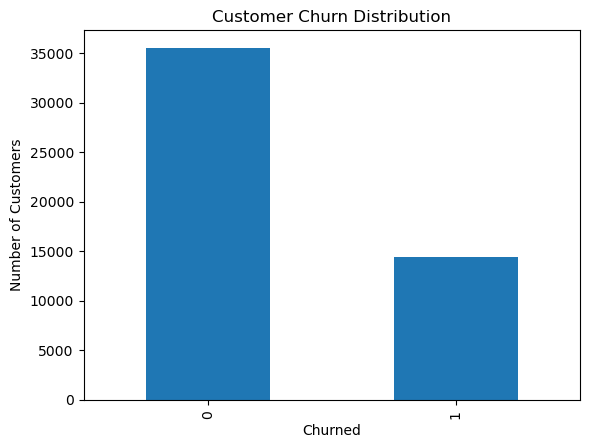

In [18]:
import matplotlib.pyplot as plt

df["Churned"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churned")
plt.ylabel("Number of Customers")
plt.show()

In [19]:
churn_rate = df["Churned"].mean() * 100

print("Churn Rate:", round(churn_rate, 2), "%")

Churn Rate: 28.9 %


In [20]:
print(df.groupby("Gender")["Churned"].mean() * 100)

Gender
Female    28.973563
Male      28.730112
Other     31.270011
Name: Churned, dtype: float64


In [21]:
print(df.groupby("Membership_Years")["Churned"].mean())

Membership_Years
0.100000     0.278481
0.107332     1.000000
0.122189     1.000000
0.134141     0.000000
0.135402     1.000000
               ...   
9.600000     0.342105
9.700000     0.310345
9.800000     0.264706
9.900000     0.291667
10.000000    0.279159
Name: Churned, Length: 200, dtype: float64


In [22]:
print(df.groupby("Churned")["Login_Frequency"].mean())

Churned
0    12.642391
1     9.120830
Name: Login_Frequency, dtype: float64


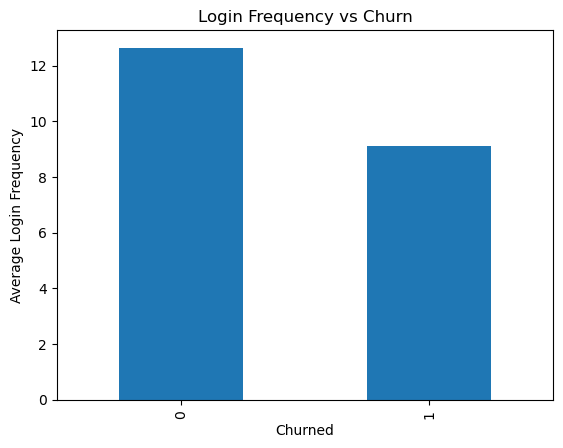

In [23]:
import matplotlib.pyplot as plt

df.groupby("Churned")["Login_Frequency"].mean().plot(kind="bar")

plt.title("Login Frequency vs Churn")
plt.xlabel("Churned")
plt.ylabel("Average Login Frequency")
plt.show()

In [24]:
print(df.groupby("Churned")["Cart_Abandonment_Rate"].mean())

Churned
0    54.194460
1    64.178935
Name: Cart_Abandonment_Rate, dtype: float64


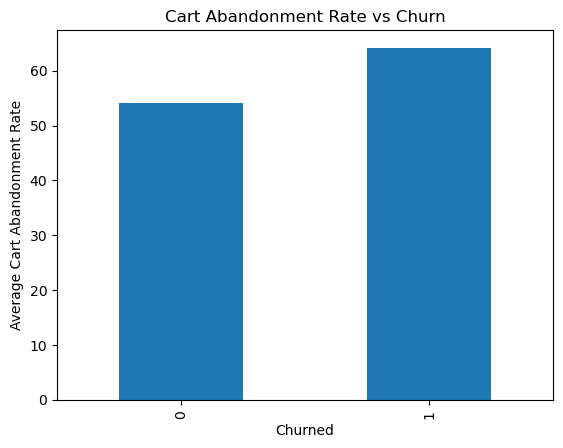

In [25]:
import matplotlib.pyplot as plt

df.groupby("Churned")["Cart_Abandonment_Rate"].mean().plot(kind="bar")

plt.title("Cart Abandonment Rate vs Churn")
plt.xlabel("Churned")
plt.ylabel("Average Cart Abandonment Rate")
plt.show()

In [26]:
print(df.groupby("Churned")["Customer_Service_Calls"].mean())

Churned
0    5.184895
1    6.896471
Name: Customer_Service_Calls, dtype: float64


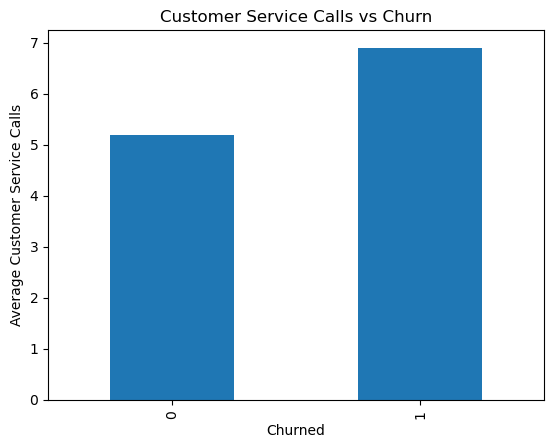

In [27]:
import matplotlib.pyplot as plt

df.groupby("Churned")["Customer_Service_Calls"].mean().plot(kind="bar")

plt.title("Customer Service Calls vs Churn")
plt.xlabel("Churned")
plt.ylabel("Average Customer Service Calls")
plt.show()

In [28]:
print(df.groupby("Churned")["Lifetime_Value"].mean())

Churned
0    1446.805875
1    1425.423236
Name: Lifetime_Value, dtype: float64


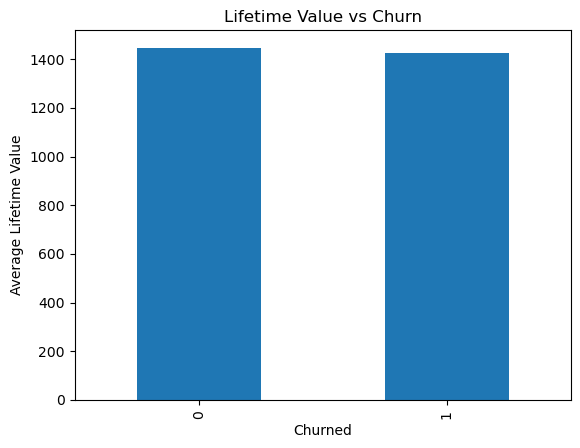

In [29]:
import matplotlib.pyplot as plt

df.groupby("Churned")["Lifetime_Value"].mean().plot(kind="bar")

plt.title("Lifetime Value vs Churn")
plt.xlabel("Churned")
plt.ylabel("Average Lifetime Value")
plt.show()

In [30]:
print("Average values for Active and Churned Customers:\n")

print("Login Frequency:")
print(df.groupby("Churned")["Login_Frequency"].mean())

print("\nCart Abandonment Rate:")
print(df.groupby("Churned")["Cart_Abandonment_Rate"].mean())

print("\nCustomer Service Calls:")
print(df.groupby("Churned")["Customer_Service_Calls"].mean())

print("\nLifetime Value:")
print(df.groupby("Churned")["Lifetime_Value"].mean())

Average values for Active and Churned Customers:

Login Frequency:
Churned
0    12.642391
1     9.120830
Name: Login_Frequency, dtype: float64

Cart Abandonment Rate:
Churned
0    54.194460
1    64.178935
Name: Cart_Abandonment_Rate, dtype: float64

Customer Service Calls:
Churned
0    5.184895
1    6.896471
Name: Customer_Service_Calls, dtype: float64

Lifetime Value:
Churned
0    1446.805875
1    1425.423236
Name: Lifetime_Value, dtype: float64


In [ ]:
Step 5 – Customer Segmentation

In [31]:
df["Customer_Segment"] = pd.cut(
    df["Lifetime_Value"],
    bins=[0, 1000, 2000, float("inf")],
    labels=["Low Value", "Medium Value", "High Value"]
)

print(df[["Lifetime_Value", "Customer_Segment"]].head())

   Lifetime_Value Customer_Segment
0          953.33        Low Value
1         1067.47     Medium Value
2         1289.75     Medium Value
3         2340.92       High Value
4         3041.29       High Value


In [32]:
print(df["Customer_Segment"].value_counts())

Customer_Segment
Medium Value    20714
Low Value       18540
High Value      10737
Name: count, dtype: int64


In [33]:
print(pd.crosstab(
    df["Customer_Segment"],
    df["Churned"],
    normalize="index"
) * 100)

Churned                   0          1
Customer_Segment                      
Low Value         64.881338  35.118662
Medium Value      81.761128  18.238872
High Value        61.320667  38.679333


In [ ]:
Step 6 – Machine Learning: Churn Prediction

In [34]:
X = df[
    [
        "Age",
        "Membership_Years",
        "Login_Frequency",
        "Session_Duration_Avg",
        "Pages_Per_Session",
        "Cart_Abandonment_Rate",
        "Wishlist_Items",
        "Email_Open_Rate",
        "Customer_Service_Calls",
        "Product_Reviews_Written",
        "Social_Media_Engagement_Score",
        "Mobile_App_Usage",
        "Payment_Method_Diversity",
        "Lifetime_Value",
        "Credit_Balance"
    ]
]

y = df["Churned"]

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000, 15)
Testing data: (10000, 15)


In [36]:
print("X and y check")

print(X.head())
print(y.head())

X and y check
    Age  Membership_Years  Login_Frequency  Session_Duration_Avg  \
0  43.0               2.9             14.0                  27.4   
1  36.0               1.6             15.0                  42.7   
2  45.0               2.9             10.0                  24.8   
3  56.0               2.6             10.0                  38.4   
4  35.0               3.1             29.0                  51.4   

   Pages_Per_Session  Cart_Abandonment_Rate  Wishlist_Items  Email_Open_Rate  \
0                6.0                   50.6             3.0             17.9   
1               10.3                   37.7             1.0             42.8   
2                1.6                   70.9             1.0              0.0   
3               14.8                   41.7             9.0             41.4   
4                8.4                   19.1             9.0             37.9   

   Customer_Service_Calls  Product_Reviews_Written  \
0                     9.0                 

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000, 15)
Testing data: (10000, 15)


In [38]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model training completed")

/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model training completed


In [39]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 1]


In [40]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 75.52 %


In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.92      0.84      7110
           1       0.64      0.35      0.46      2890

    accuracy                           0.76     10000
   macro avg       0.71      0.64      0.65     10000
weighted avg       0.74      0.76      0.73     10000



In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[6527  583]
 [1865 1025]]


In [43]:
risk_score = model.predict_proba(X_test)[:, 1]

print(risk_score[:10])

[0.03681626 0.13831304 0.31080505 0.23364824 0.06474109 0.08327597
 0.07868214 0.0164587  0.17051901 0.79780643]


In [44]:
def risk_level(score):
    if score >= 0.70:
        return "High Risk"
    elif score >= 0.30:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_levels = [risk_level(score) for score in risk_score]

print(risk_levels[:10])

['Low Risk', 'Low Risk', 'Medium Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'Low Risk', 'High Risk']


In [45]:
prediction_df = X_test.copy()

prediction_df["Actual_Churn"] = y_test.values
prediction_df["Churn_Probability"] = risk_score
prediction_df["Risk_Level"] = risk_levels

print(prediction_df.head())

        Age  Membership_Years  Login_Frequency  Session_Duration_Avg  \
25530  41.0               4.3             26.0                  47.5   
35326  37.0               2.7             15.0                  26.0   
35816  32.0               4.8             13.0                   8.4   
14081  38.0               1.2              6.0                  30.2   
17232  24.0               5.9             20.0                  35.4   

       Pages_Per_Session  Cart_Abandonment_Rate  Wishlist_Items  \
25530               15.0                   46.8             7.0   
35326               10.6                   46.9             3.0   
35816                3.7                   63.0             7.0   
14081                8.1                   60.7             7.0   
17232                9.2                   18.3             7.0   

       Email_Open_Rate  Customer_Service_Calls  Product_Reviews_Written  \
25530             40.2                     1.0                      3.0   
35326         

In [46]:
print(prediction_df["Risk_Level"].value_counts())

Risk_Level
Low Risk       5629
Medium Risk    4067
High Risk       304
Name: count, dtype: int64


In [47]:
prediction_df.to_csv("customer_churn_predictions.csv", index=False)

print("Prediction file saved successfully")

Prediction file saved successfully


In [48]:
powerbi_df = df.loc[X_test.index].copy()

powerbi_df["Predicted_Churn"] = y_pred
powerbi_df["Churn_Probability"] = risk_score
powerbi_df["Risk_Level"] = risk_levels

powerbi_df.to_csv("ecommerce_churn_powerbi.csv", index=False)

In [49]:
print("File created successfully!")
print(powerbi_df.shape)

File created successfully!
(10000, 29)
